**Objective**:

Practice core data analysis skills using NumPy, Pandas, Matplotlib, and Seaborn by exploring a simple real-world dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load Titanic datasets using Pandas
titanic = pd.read_csv("titanic.csv")
df = pd.DataFrame(titanic)

In [22]:
# Inspect the shape, columns, and basic information
print("Shape:",titanic.shape)
print("Columns:", ', '.join(list(titanic.columns)))
print("Info:\n", titanic.info)

Shape: (891, 12)
Columns: PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked
Info:
 <bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   

In [25]:
# Check for missing values and handle them appropriately
df['Age'].fillna(df['Age'].mean(), inplace=True)
df.drop('Cabin',axis=1, inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_676/198118209.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_676/198118209.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [26]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [33]:
# Find how many passengers survived and did not survive
print(f"Survived: {(df['Survived'] == 1).sum()}")
print(f"Di not survived: {(df['Survived'] == 0).sum()}")

Survived: 342
Di not survived: 549


In [51]:
# Analyze survival based on gender
df.groupby('Sex')['Survived'].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

In [45]:
# Analyze survival based on gender

df.groupby('Pclass')['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

In [47]:
print("Average fare:", df['Fare'].mean())
print("Average Age: ", df['Age'].mean())

Average fare: 32.204207968574636
Average Age:  29.69911764705882


Text(0, 0.5, 'Passenger Count')

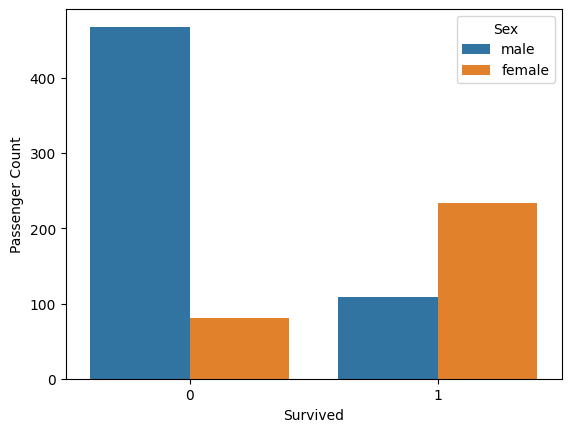

In [53]:
sns.countplot(data = df, x = 'Survived', hue = 'Sex' )
plt.ylabel("Passenger Count")

<Axes: xlabel='Survived', ylabel='count'>

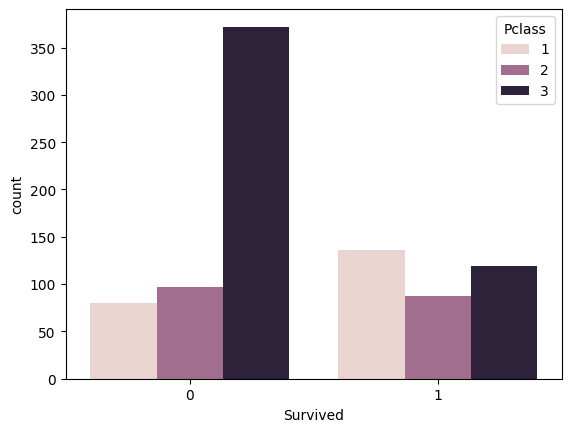

In [57]:
sns.countplot(data = df, x = 'Survived', hue = 'Pclass')

<Axes: xlabel='Age', ylabel='Count'>

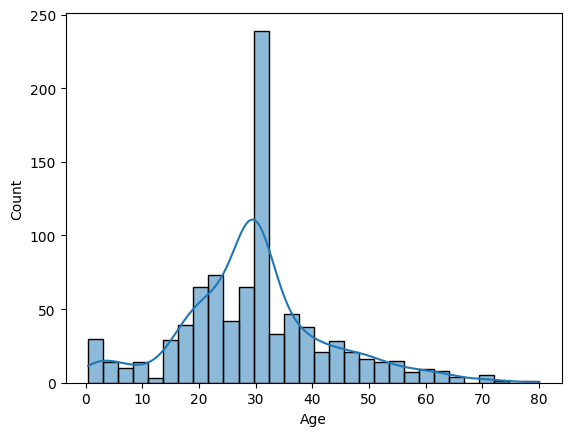

In [63]:


sns.histplot(df['Age'], kde = True, bins = 30)

Text(0.5, 1.0, 'Fare distribution for survivors vs non-survivors')

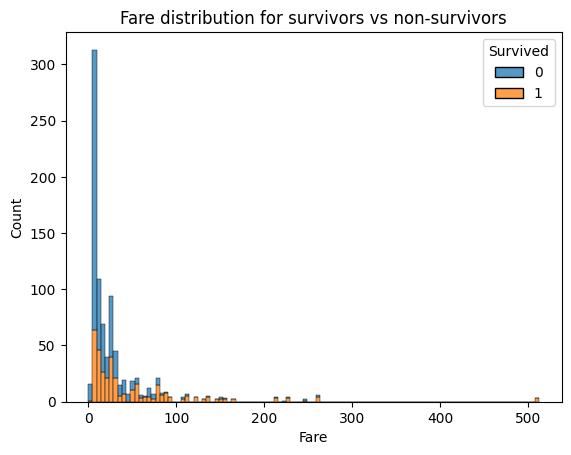

In [72]:
sns.histplot(data = df, x = 'Fare', hue = 'Survived', multiple = 'stack')
plt.title("Fare distribution for survivors vs non-survivors")

Text(0, 0.5, 'Survival Rates')

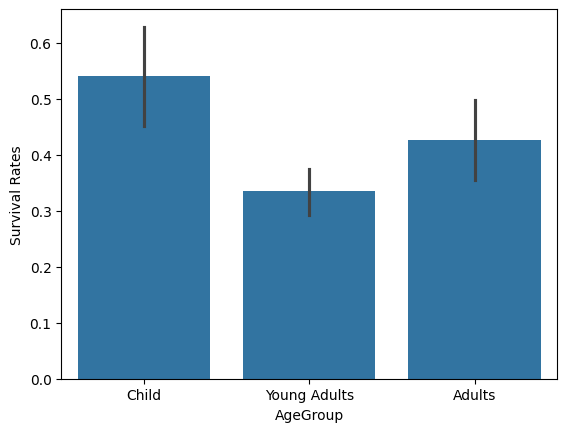

In [62]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins = [0, 17, 31, 45],
    labels = ['Child', 'Young Adults', 'Adults']
)

sns.barplot(data = df, x = 'AgeGroup', y = 'Survived')
plt.ylabel("Survival Rates")